In [1]:
import torch
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image


/home/patil139/scratch/adversarial-simulation/.venv/lib/python3.12/site-packages/PIL/Image.py:3432: DecompressionBombWarning: Image size (134640000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [2]:
processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vit7b16-pretrain-lvd1689m")
model = AutoModel.from_pretrained(
    "facebook/dinov3-vit7b16-pretrain-lvd1689m",
    dtype=torch.float16,
    device_map="auto",
    attn_implementation="sdpa",
)

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

In [41]:
patch_size = model.config.patch_size
img_size = 1024

image = load_image("test/20231077135.jpg")
# image = load_image("test/pexels-rachel-claire-5864750.jpg")

inputs = processor(images=image, size={"height": img_size, "width": img_size}, return_tensors="pt").to(model.device)

batch_size, _, img_height, img_width = inputs.pixel_values.shape
num_patches_height, num_patches_width = img_height // patch_size, img_width // patch_size
num_patches_flat = num_patches_height * num_patches_width

print(inputs.pixel_values.shape)
assert inputs.pixel_values.shape == (batch_size, 3, num_patches_height * patch_size, num_patches_width * patch_size)

torch.Size([1, 3, 1024, 1024])


In [36]:
with torch.inference_mode():
  outputs = model(**inputs)

last_hidden_states = outputs.last_hidden_state
assert last_hidden_states.shape == (batch_size, 1 + model.config.num_register_tokens + num_patches_flat, model.config.hidden_size)

cls_token = last_hidden_states[:, 0, :]
patch_features_flat = last_hidden_states[:, 1 + model.config.num_register_tokens:, :]
patch_features = patch_features_flat.unflatten(1, (num_patches_height, num_patches_width))
print(cls_token.shape)
print(patch_features.shape)
assert cls_token.shape == (batch_size, model.config.hidden_size)
assert patch_features.shape == (batch_size, num_patches_height, num_patches_width, model.config.hidden_size)

torch.Size([1, 4096])
torch.Size([1, 64, 64, 4096])


In [37]:
import numpy as np
import torch.nn.functional as F
from PIL import Image as PILImage

DISPLAY_SIZE = 1024
NUM_PATCHES = num_patches_height  # 256

# L2-normalize patch features (fp32 for numerical stability)
feats_flat = patch_features[0].reshape(-1, model.config.hidden_size)  # (65536, 4096)
feats_norm = F.normalize(feats_flat.float(), dim=-1)  # (65536, 4096) fp32 on GPU

# Displayable image (1024x1024)
img_display = np.array(image.resize((DISPLAY_SIZE, DISPLAY_SIZE), PILImage.LANCZOS))

print(f"feats_norm: {feats_norm.shape}, device={feats_norm.device}")
print(f"img_display: {img_display.shape}")

feats_norm: torch.Size([4096, 4096]), device=cuda:0
img_display: (1024, 1024, 3)


Click on the image to visualize self-similarity.


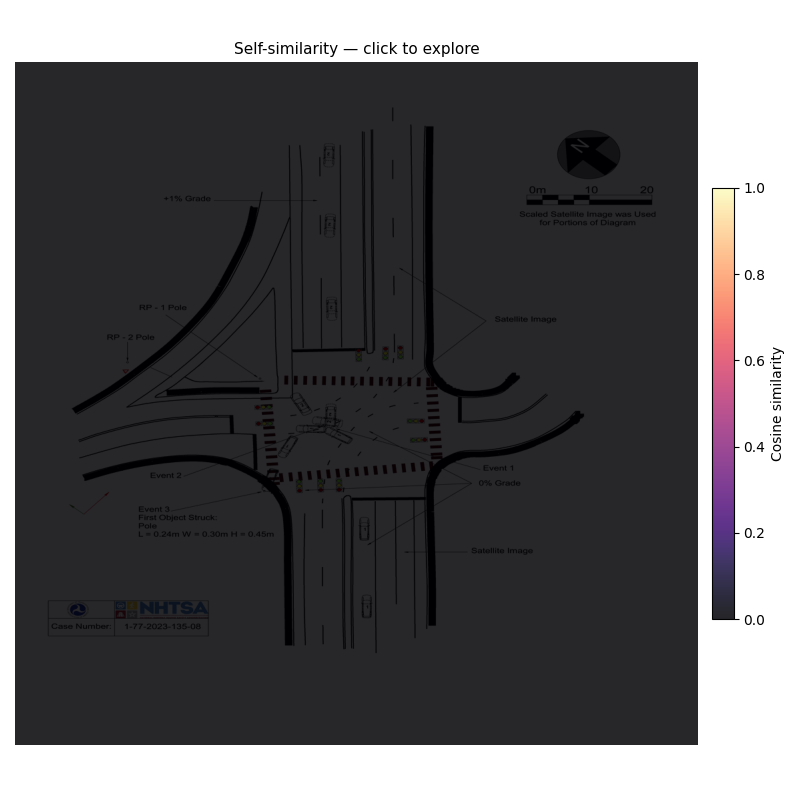

In [38]:
%matplotlib widget
import matplotlib.pyplot as plt

COLORMAP = "magma"
OVERLAY_ALPHA = 0.85

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Self-similarity — click to explore", fontsize=11)
ax.axis("off")

# Background image
ax.imshow(img_display, origin="upper", zorder=0)

# Similarity overlay (256×256 array stretched over full image via extent)
_blank = np.zeros((NUM_PATCHES, NUM_PATCHES), dtype=np.float32)
overlay = ax.imshow(
    _blank, cmap=COLORMAP, vmin=0, vmax=1.0, alpha=OVERLAY_ALPHA,
    origin="upper",
    extent=[-0.5, DISPLAY_SIZE - 0.5, DISPLAY_SIZE - 0.5, -0.5],
    zorder=1, interpolation="none",
)
fig.colorbar(overlay, ax=ax, fraction=0.03, pad=0.02).set_label("Cosine similarity")

# Marker for the clicked patch
(marker,) = ax.plot([], [], marker="s", markersize=6, color="cyan",
                    markeredgecolor="black", markeredgewidth=0.8, linewidth=0, zorder=2)

fig.tight_layout()

def _pixel_to_patch(x, y):
    """Map display data coords → patch (i=row, j=col), or None if out of bounds."""
    if x is None or y is None:
        return None
    scale = NUM_PATCHES / DISPLAY_SIZE
    i, j = int(y * scale), int(x * scale)
    return (i, j) if 0 <= i < NUM_PATCHES and 0 <= j < NUM_PATCHES else None

def on_click(event):
    if event.inaxes is not ax or event.button != 1:
        return
    patch = _pixel_to_patch(event.xdata, event.ydata)
    if patch is None:
        return
    i, j = patch

    query = feats_norm[i * NUM_PATCHES + j]  # (4096,)
    sims = (feats_norm @ query).reshape(NUM_PATCHES, NUM_PATCHES).cpu().numpy()

    overlay.set_data(sims)
    patch_px = DISPLAY_SIZE / NUM_PATCHES
    marker.set_data([(j + 0.5) * patch_px], [(i + 0.5) * patch_px])
    fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", on_click)
print("Click on the image to visualize self-similarity.")

Hover over the image to visualize self-similarity.


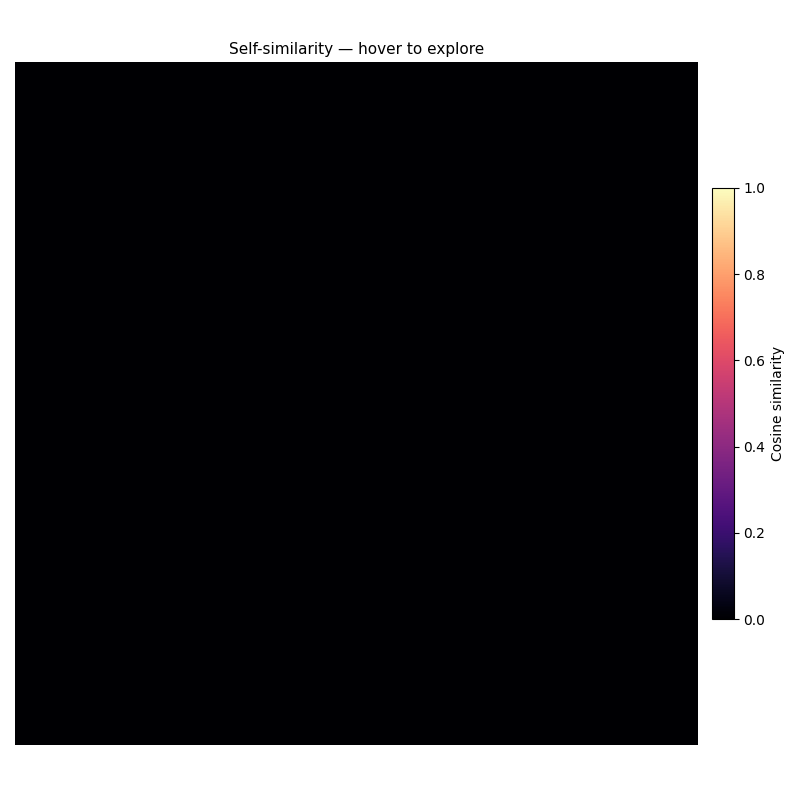

In [40]:
%matplotlib widget
import matplotlib.pyplot as plt
import time

COLORMAP = "magma"
OVERLAY_ALPHA = 1
THROTTLE_MS = 1

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title("Self-similarity — hover to explore", fontsize=11)
ax.axis("off")

# Background image
ax.imshow(img_display, origin="upper", zorder=0)

# Similarity overlay (256×256 array stretched over full image via extent)
_blank = np.zeros((NUM_PATCHES, NUM_PATCHES), dtype=np.float32)
overlay = ax.imshow(
    _blank, cmap=COLORMAP, vmin=0, vmax=1.0, alpha=OVERLAY_ALPHA,
    origin="upper",
    extent=[-0.5, DISPLAY_SIZE - 0.5, DISPLAY_SIZE - 0.5, -0.5],
    zorder=1, interpolation="none",
)
fig.colorbar(overlay, ax=ax, fraction=0.03, pad=0.02).set_label("Cosine similarity")

# Marker for the hovered patch
(marker,) = ax.plot([], [], marker="s", markersize=6, color="cyan",
                    markeredgecolor="black", markeredgewidth=0.8, linewidth=0, zorder=2)

fig.tight_layout()

_last_patch = (-1, -1)
_last_t = 0.0

def _pixel_to_patch(x, y):
    """Map display data coords → patch (i=row, j=col), or None if out of bounds."""
    if x is None or y is None:
        return None
    scale = NUM_PATCHES / DISPLAY_SIZE
    i, j = int(y * scale), int(x * scale)
    return (i, j) if 0 <= i < NUM_PATCHES and 0 <= j < NUM_PATCHES else None

def on_move(event):
    global _last_patch, _last_t
    if event.inaxes is not ax:
        return
    # now = time.monotonic()
    # if (now - _last_t) * 1000 < THROTTLE_MS:
    #     return
    patch = _pixel_to_patch(event.xdata, event.ydata)
    if patch is None or patch == _last_patch:
        return
    i, j = patch
    _last_patch, _last_t = (i, j)#, now

    query = feats_norm[i * NUM_PATCHES + j]  # (4096,)
    sims = (feats_norm @ query).reshape(NUM_PATCHES, NUM_PATCHES).cpu().numpy()

    overlay.set_data(sims)
    patch_px = DISPLAY_SIZE / NUM_PATCHES
    marker.set_data([(j + 0.5) * patch_px], [(i + 0.5) * patch_px])
    fig.canvas.draw_idle()

fig.canvas.mpl_connect("motion_notify_event", on_move)
print("Hover over the image to visualize self-similarity.")